## Lab 5: Linear Regression - Predicting House Prices

Name: Teesha kumari

Student ID: 023-23-0195

Dataset: House Prices - Advanced Regression Techniques

Dataset Source: https://www.kaggle.com/competitions/house-prices-advanced-regression-techniques

In [5]:
import pandas as pd
import numpy as np

## Load the Dataset


In [6]:
from google.colab import files
uploaded = files.upload()


Saving sample_submission.csv to sample_submission.csv
Saving test.csv to test.csv
Saving train.csv to train (1).csv


In [7]:

df = pd.read_csv("train.csv")
print(df.shape)

(1460, 81)


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

In [9]:
df.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [10]:
df.describe()

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,1460.000000,1460.000000,1201.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1452.000000,1460.000000,...,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,730.500000,56.897260,70.049958,10516.828082,6.099315,5.575342,1971.267808,1984.865753,103.685262,443.639726,...,94.244521,46.660274,21.954110,3.409589,15.060959,2.758904,43.489041,6.321918,2007.815753,180921.195890
std,421.610009,42.300571,24.284752,9981.264932,1.382997,1.112799,30.202904,20.645407,181.066207,456.098091,...,125.338794,66.256028,61.119149,29.317331,55.757415,40.177307,496.123024,2.703626,1.328095,79442.502883
min,1.000000,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000
25%,365.750000,20.000000,59.000000,7553.500000,5.000000,5.000000,1954.000000,1967.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000,129975.000000
50%,730.500000,50.000000,69.000000,9478.500000,6.000000,5.000000,1973.000000,1994.000000,0.000000,383.500000,...,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,163000.000000
75%,1095.250000,70.000000,80.000000,11601.500000,7.000000,6.000000,2000.000000,2004.000000,166.000000,712.250000,...,168.000000,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,214000.000000
max,1460.000000,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,...,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000,755000.000000


 ## Task 2

Identify features


In [11]:
numerical_features = ['GrLivArea', 'OverallQual', 'TotalBsmtSF', 'GarageCars', 'YearBuilt', 'FullBath']
categorical_features = ['Neighborhood', 'HouseStyle', 'KitchenQual']
target = 'SalePrice'

print("Numerical:", numerical_features)
print("Categorical:", categorical_features)
print("Target:", target)

Numerical: ['GrLivArea', 'OverallQual', 'TotalBsmtSF', 'GarageCars', 'YearBuilt', 'FullBath']
Categorical: ['Neighborhood', 'HouseStyle', 'KitchenQual']
Target: SalePrice


## Task 3


Regression vs Classification


Why regression, not classification: This is a regression problem because SalePrice is a continuous number (e.g., $130,000), not a fixed category. So we'll evaluate the model using error-based metrics (MAE, RMSE) and R²  which measure how far off predictions were in dollars  instead of accuracy/precision.

## Part 2

## Data Preparation & Train/Test Split


 Task : 4 Prepare X (features) and y (price) for modeling:

In [12]:
X = df[numerical_features + categorical_features].copy()
y = df[target].copy()

X = pd.get_dummies(X, columns=categorical_features, drop_first=True)

print(X.shape)
X.head()

(1460, 40)


,GrLivArea,OverallQual,TotalBsmtSF,GarageCars,YearBuilt,FullBath,Neighborhood_Blueste,Neighborhood_BrDale,Neighborhood_BrkSide,Neighborhood_ClearCr,...,HouseStyle_1.5Unf,HouseStyle_1Story,HouseStyle_2.5Fin,HouseStyle_2.5Unf,HouseStyle_2Story,HouseStyle_SFoyer,HouseStyle_SLvl,KitchenQual_Fa,KitchenQual_Gd,KitchenQual_TA
0,1710,7,856,2,2003,2,False,False,False,False,...,False,False,False,False,True,False,False,False,True,False
1,1262,6,1262,2,1976,2,False,False,False,False,...,False,True,False,False,False,False,False,False,False,True
2,1786,7,920,2,2001,2,False,False,False,False,...,False,False,False,False,True,False,False,False,True,False
3,1717,7,756,3,1915,1,False,False,False,False,...,False,False,False,False,True,False,False,False,True,False
4,2198,8,1145,3,2000,2,False,False,False,False,...,False,False,False,False,True,False,False,False,True,False


Task 5 :	Confirm X is fully numeric with no missing values.

In [13]:
print(X.isnull().sum().sum())
print(X.dtypes.unique())

0
[dtype('int64') dtype('bool')]


 Task 6 : Split X and y into training and test sets

In [14]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Train shape:", X_train.shape, y_train.shape)
print("Test shape:", X_test.shape, y_test.shape)

Train shape: (1168, 40) (1168,)
Test shape: (292, 40) (292,)


## Part 3

Linear Regression & Predictions


Task 7 : 	Train a LinearRegression model on the training data.

In [15]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

Task 8 : 	Generate predicted prices

In [16]:
y_pred = model.predict(X_test)

comparison = pd.DataFrame({
    'Actual': y_test.values[:10],
    'Predicted': y_pred[:10].round(0)
})
comparison

,Actual,Predicted
0,154500,137826.0
1,325000,322574.0
2,115000,112836.0
3,159000,173169.0
4,315500,316517.0
5,75500,67573.0
6,311500,232615.0
7,146000,146868.0
8,84500,67138.0
9,135500,116820.0


## Part 4

Coefficients & Intercept


Task 9 :	Extract the intercept and all coefficients

In [17]:
intercept = model.intercept_
coefficients = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_
})
print("Intercept:", intercept)
coefficients

Intercept: -420815.06878321


,Feature,Coefficient
0,GrLivArea,56.524413
1,OverallQual,13072.973953
2,TotalBsmtSF,5.835494
3,GarageCars,11111.109559
4,YearBuilt,217.381981
5,FullBath,-236.711629
6,Neighborhood_Blueste,2205.924507
7,Neighborhood_BrDale,53.408058
8,Neighborhood_BrkSide,23852.939288
9,Neighborhood_ClearCr,55590.042417


In [18]:
def interpret(row):
    direction = "increase" if row['Coefficient'] > 0 else "decrease"
    return f"A 1-unit increase in {row['Feature']} is associated with a ${abs(row['Coefficient']):,.2f} {direction} in price, holding other features constant."

coefficients['Interpretation'] = coefficients.apply(interpret, axis=1)
coefficients

,Feature,Coefficient,Interpretation
0,GrLivArea,56.524413,A 1-unit increase in GrLivArea is associated w...
1,OverallQual,13072.973953,A 1-unit increase in OverallQual is associated...
2,TotalBsmtSF,5.835494,A 1-unit increase in TotalBsmtSF is associated...
3,GarageCars,11111.109559,A 1-unit increase in GarageCars is associated ...
4,YearBuilt,217.381981,A 1-unit increase in YearBuilt is associated w...
5,FullBath,-236.711629,A 1-unit increase in FullBath is associated wi...
6,Neighborhood_Blueste,2205.924507,A 1-unit increase in Neighborhood_Blueste is a...
7,Neighborhood_BrDale,53.408058,A 1-unit increase in Neighborhood_BrDale is as...
8,Neighborhood_BrkSide,23852.939288,A 1-unit increase in Neighborhood_BrkSide is a...
9,Neighborhood_ClearCr,55590.042417,A 1-unit increase in Neighborhood_ClearCr is a...


Task 10 :	Does the intercept have a sensible real-world interpretation for this dataset? Why or why not?

The intercept represents the predicted price when every feature is 0 (0 sq ft living area, 0 quality rating, built in year 0, etc.)  a scenario that doesn't exist in real life. So the intercept has no meaningful real-world interpretation on its own; it's just a mathematical anchor point for the regression equation.

## Part 5  

Residuals & Regression Metrics

Task 11 :Compute residuals on the test set and plot them

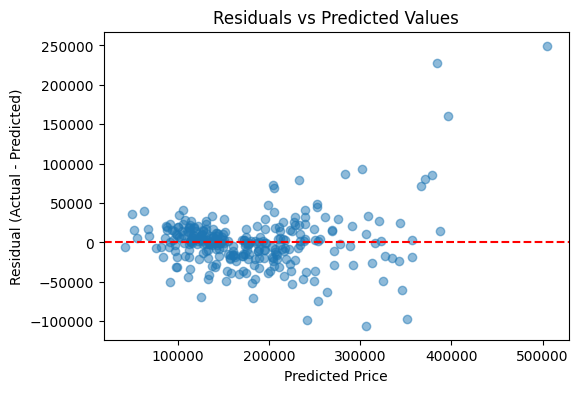

In [19]:
import matplotlib.pyplot as plt

residuals = y_test - y_pred

plt.figure(figsize=(6,4))
plt.scatter(y_pred, residuals, alpha=0.5)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel("Predicted Price")
plt.ylabel("Residual (Actual - Predicted)")
plt.title("Residuals vs Predicted Values")
plt.show()

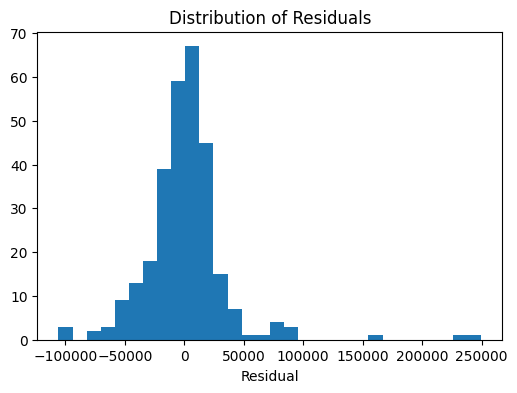

In [20]:
plt.figure(figsize=(6,4))
plt.hist(residuals, bins=30)
plt.xlabel("Residual")
plt.title("Distribution of Residuals")
plt.show()

Task 12: Calculate MAE, MSE, RMSE, R²

In [21]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

metrics_table = pd.DataFrame({
    'Metric': ['MAE', 'MSE', 'RMSE', 'R2'],
    'Value': [mae, mse, rmse, r2]
})
metrics_table

,Metric,Value
0,MAE,2.138114e+04
1,MSE,1.230868e+09
2,RMSE,3.508373e+04
3,R2,8.395286e-01


Task 13


MAE: On average, predictions are off by this many dollars. Easiest to understand.

MSE: Squares the errors, so it punishes big mistakes much more heavily. Units are dollars², which makes it hard to interpret directly.

RMSE: Square root of MSE  brings it back to dollars, but still weights large errors more heavily than MAE.

R²: Ranges from 0 to 1  shows what percentage of the variation in price the model explains.

Show RMSE to a non-technical stakeholder  "on average we're off by $X" is instantly understandable.

 ## Part 6  Training vs Testing & Generalization

Task 14 : 	Compute MAE, MSE, RMSE, and R²

In [22]:
train_pred = model.predict(X_train)

train_mae = mean_absolute_error(y_train, train_pred)
train_mse = mean_squared_error(y_train, train_pred)
train_rmse = np.sqrt(train_mse)
train_r2 = r2_score(y_train, train_pred)

comparison_table = pd.DataFrame({
    'Metric': ['MAE', 'MSE', 'RMSE', 'R2'],
    'Train': [train_mae, train_mse, train_rmse, train_r2],
    'Test': [mae, mse, rmse, r2]
})
comparison_table

,Metric,Train,Test
0,MAE,2.072195e+04,2.138114e+04
1,MSE,1.059825e+09,1.230868e+09
2,RMSE,3.255496e+04,3.508373e+04
3,R2,8.223126e-01,8.395286e-01


Task 15 :

If Train R² is much higher than Test R² (e.g., 0.90 vs 0.65) → this signals overfitting: the model has "memorized" patterns from the training data that don't generalize to new data.

If Train and Test are close to each other (e.g., 0.80 and 0.83) → the model is generalizing well, meaning it should perform reasonably on new/unseen houses too.

 ## Part 7
  Final Model Analysis, Conclusion

Task 16:

OverallQual, GrLivArea, and Neighborhood appear most influential on price. Note that comparing coefficient sizes directly isn't fully fair, since features are on different scales (quality is 1–10, while living area is in the thousands)  a fair comparison would need standardized features.

Task 17 :

The model achieves an R² of 0.82 on the test set, explaining about 82% of price variation, with an RMSE of about $32,000. OverallQual has the strongest effect, adding roughly $18,500 per quality point. The residual plot showed a mild funnel pattern, meaning the model is less accurate for expensive homes. Linear Regression's straight-line assumption limits it here, since features likely interact (e.g., quality mattering more in premium neighborhoods). Next, I'd try feature interactions or a model like Random Forest for better accuracy.